<a href="https://colab.research.google.com/github/eminorx/Plotting-with-Seaborn-/blob/main/Plotting_with_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plotting with Seaborn
Seaborn is a Python visualization library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics.

Firstly, let's import libraries and our data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')

print('Data read into a pandas dataframe!')

Data read into a pandas dataframe!


In [4]:
df_can.head()

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


In [5]:
df_can.set_index('Country', inplace=True)

**1. Categorical Plots**

In our data 'df_can', let's find out how many continents are mentioned

In [8]:
df_can["Continent"].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania',
       'Latin America and the Caribbean', 'Northern America'],
      dtype=object)

# countplot
**A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.** Let's find the count of Continents in the data 'df_can' using countplot on 'Continent'

<Axes: xlabel='Continent', ylabel='count'>

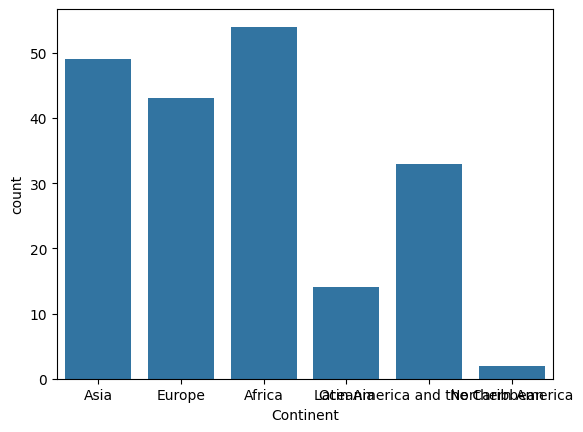

In [9]:
sns.countplot(x='Continent',data=df_can)

The labels on the x-axis doesnot look as expected.
Let's try to replace the 'Latin America and the Caribbean' with and "L-America", 'Northern America' with "N-America",
and change the figure size and then display the plot again

In [10]:
df_can1 = df_can.replace("Latin America and the Caribbean","L-America")
df_can1 = df_can1.replace("Northern America","N-America")

<Axes: xlabel='Continent', ylabel='count'>

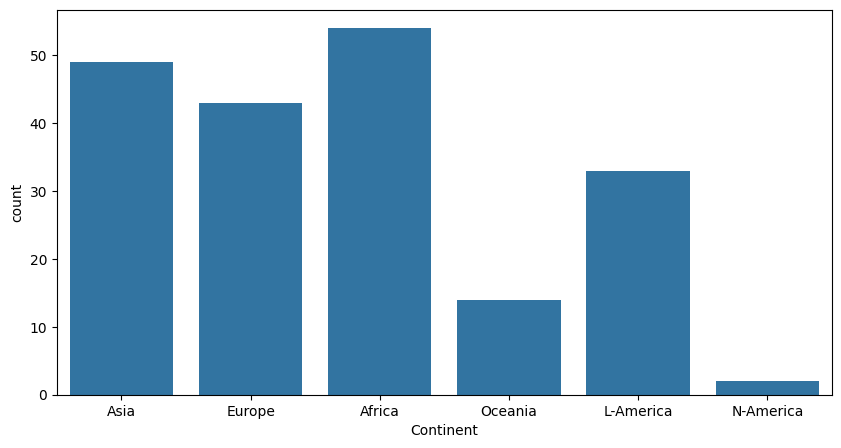

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x="Continent",data=df_can1)

# Barplot
**This plot will perform the Groupby on a categorical varaible and plot aggregated values, with confidence intervals.**

Let's plot the total immigrants Continent-wise

<Axes: xlabel='Continent', ylabel='Total'>

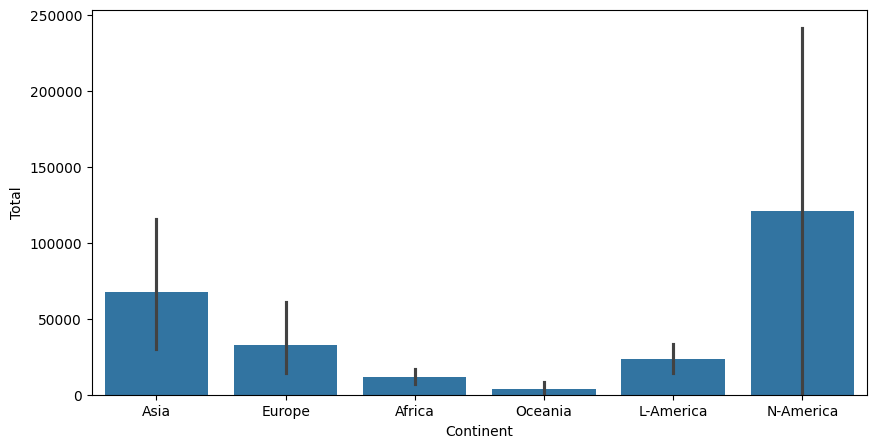

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x="Continent",y="Total",data=df_can1)

You can verify the values by performing the groupby on the Total and Continent for mean()

In [13]:
df_can2 = df_can1.groupby("Continent")['Total'].mean()
df_can2

,Total
Continent,
Africa,11462.000000
Asia,67710.081633
Europe,32812.720930
L-America,23186.303030
N-America,120571.000000
Oceania,3941.000000


# Regression Plot


In [16]:
years = list(map(str,range(1980,2014)))
# we can use the sum() method to get the total population per year
df_tot = pd.DataFrame(df_can[years].sum(axis=0))

#change the years to type float (useful for regression later on)
df_tot.index = map(float,df_tot.index)

#reset the index to put in back in as a column in the df_tot dataframe
df_tot.reset_index(inplace=True)

#rename columns
df_tot.columns = ['years','total']

#view the final dataframe
df_tot.head()

,years,total
0,1980.0,99137
1,1981.0,110563
2,1982.0,104271
3,1983.0,75550
4,1984.0,73417


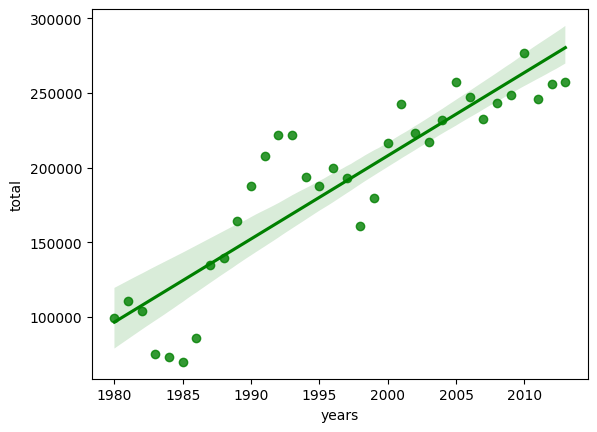

In [18]:
sns.regplot(x="years",y="total",data=df_tot,color="green")
plt.show()

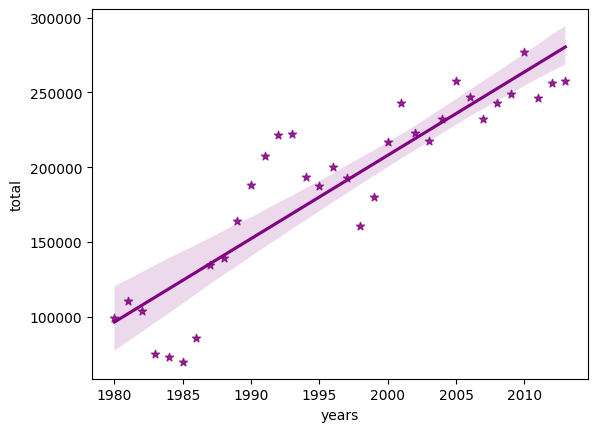

In [20]:
ax = sns.regplot(x="years",y="total",data=df_tot,color="purple",marker="*")
plt.show()

Let's blow up the plot a little so that it is more appealing to the sight.

<Axes: xlabel='years', ylabel='total'>

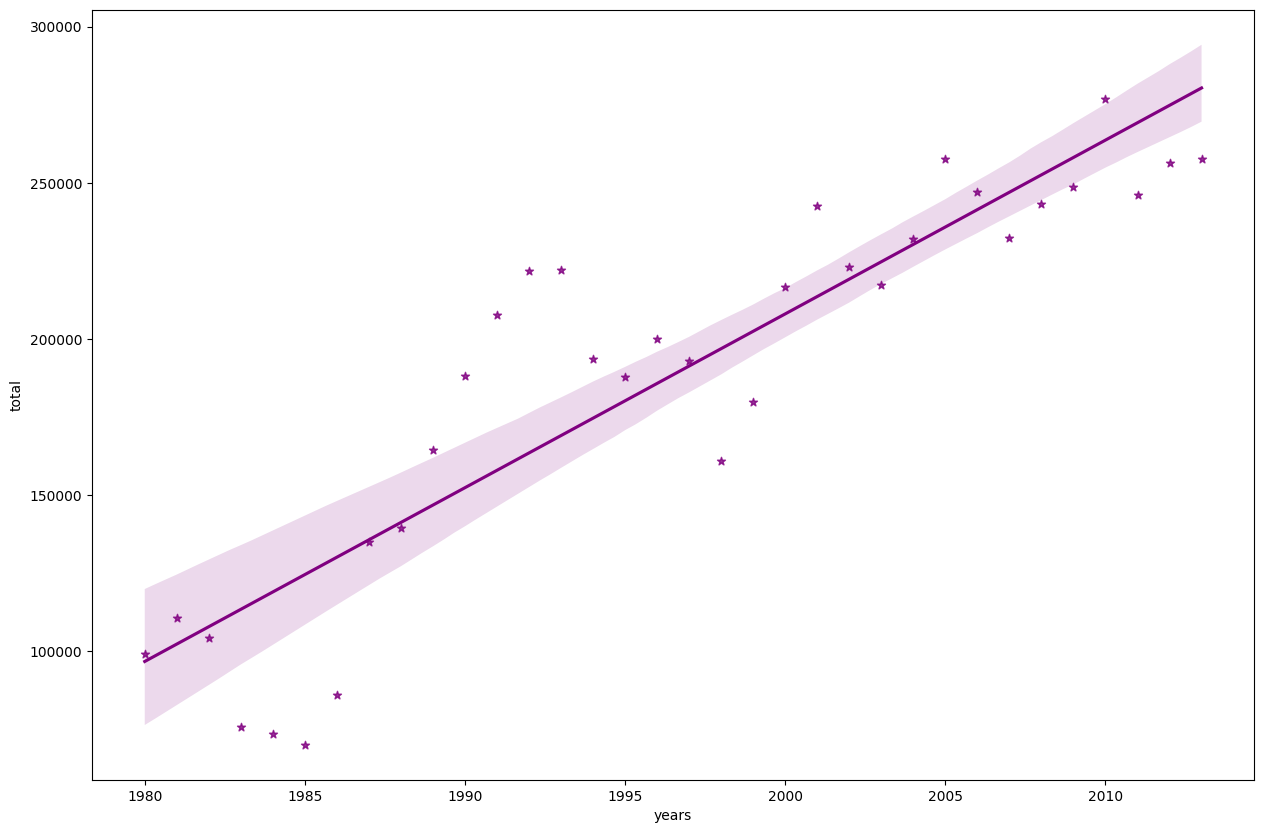

In [22]:
plt.figure(figsize=(15,10))
sns.regplot(x="years",y="total",data=df_tot,color='purple',marker="*")

And let's increase the size of markers so they match the new size of the figure, and add a title and x- and y-labels.

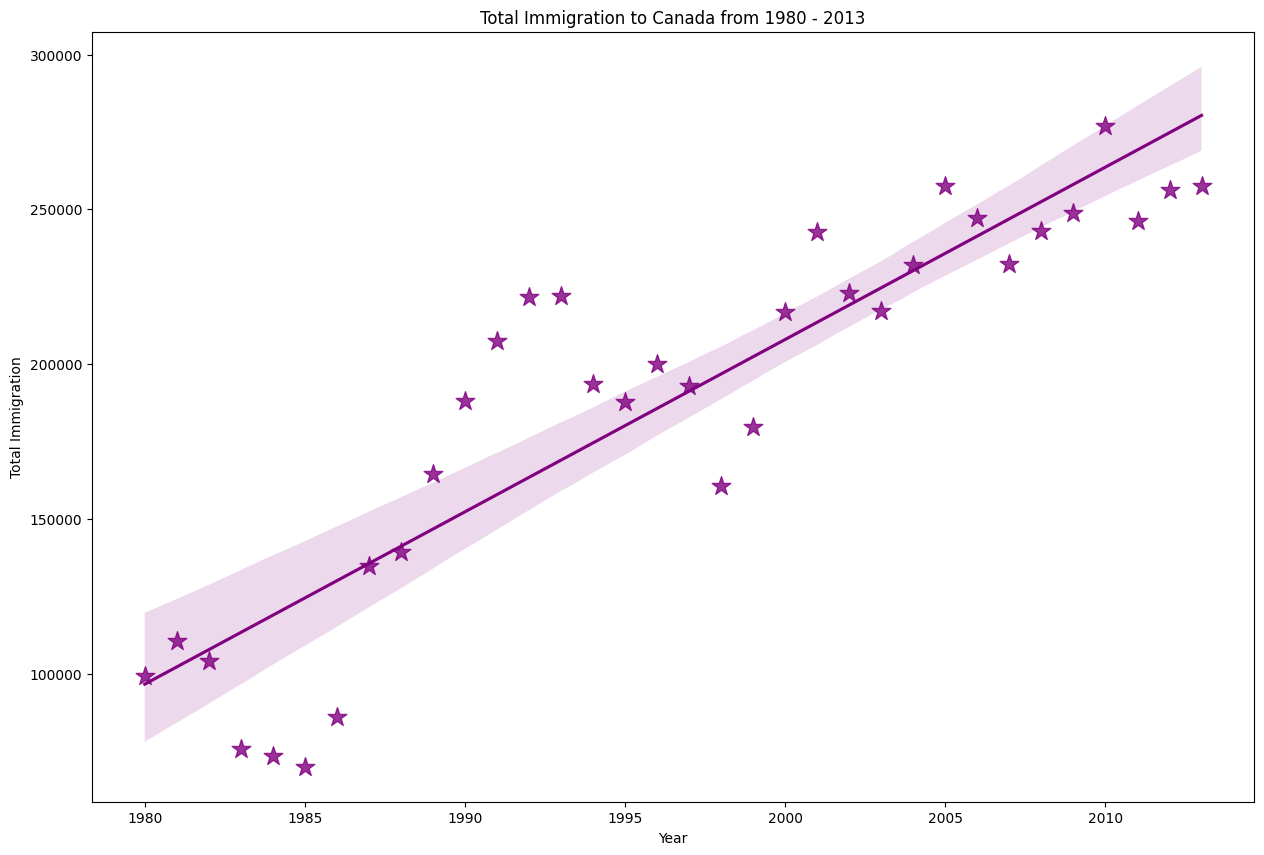

In [25]:
plt.figure(figsize=(15,10))
ax = sns.regplot(x="years",y="total",data=df_tot,color="purple",marker="*",scatter_kws={'s':200})

ax.set(xlabel='Year', ylabel='Total Immigration') # add x- and y-labels
ax.set_title('Total Immigration to Canada from 1980 - 2013') # add title
plt.show()

And finally increase the font size of the tickmark labels, the title, and the x- and y-labels so they don't feel left out!

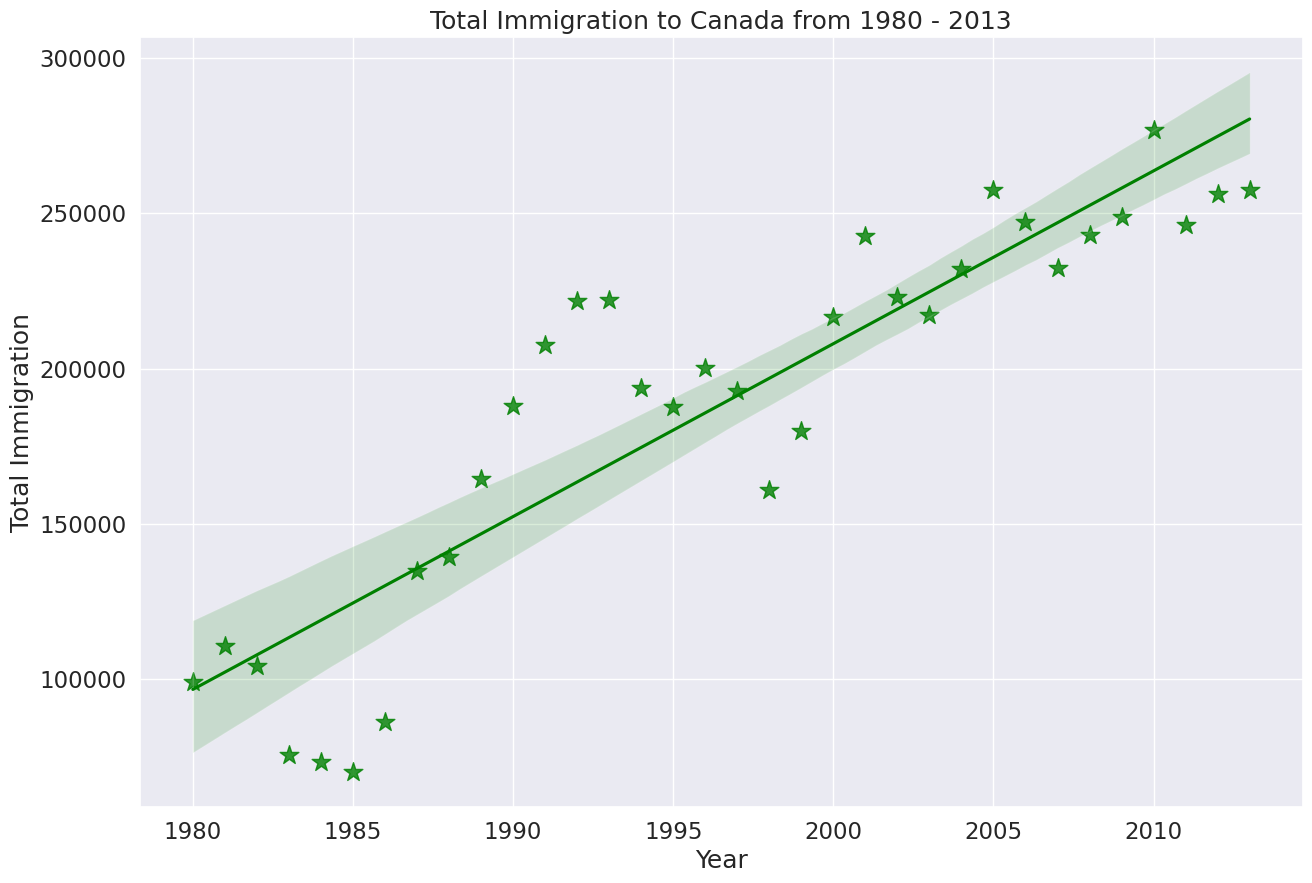

In [28]:
plt.figure(figsize=(15, 10))

sns.set(font_scale=1.5)

ax = sns.regplot(x='years', y='total', data=df_tot, color='green', marker='*', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

you can easily change the style to a white plain background.

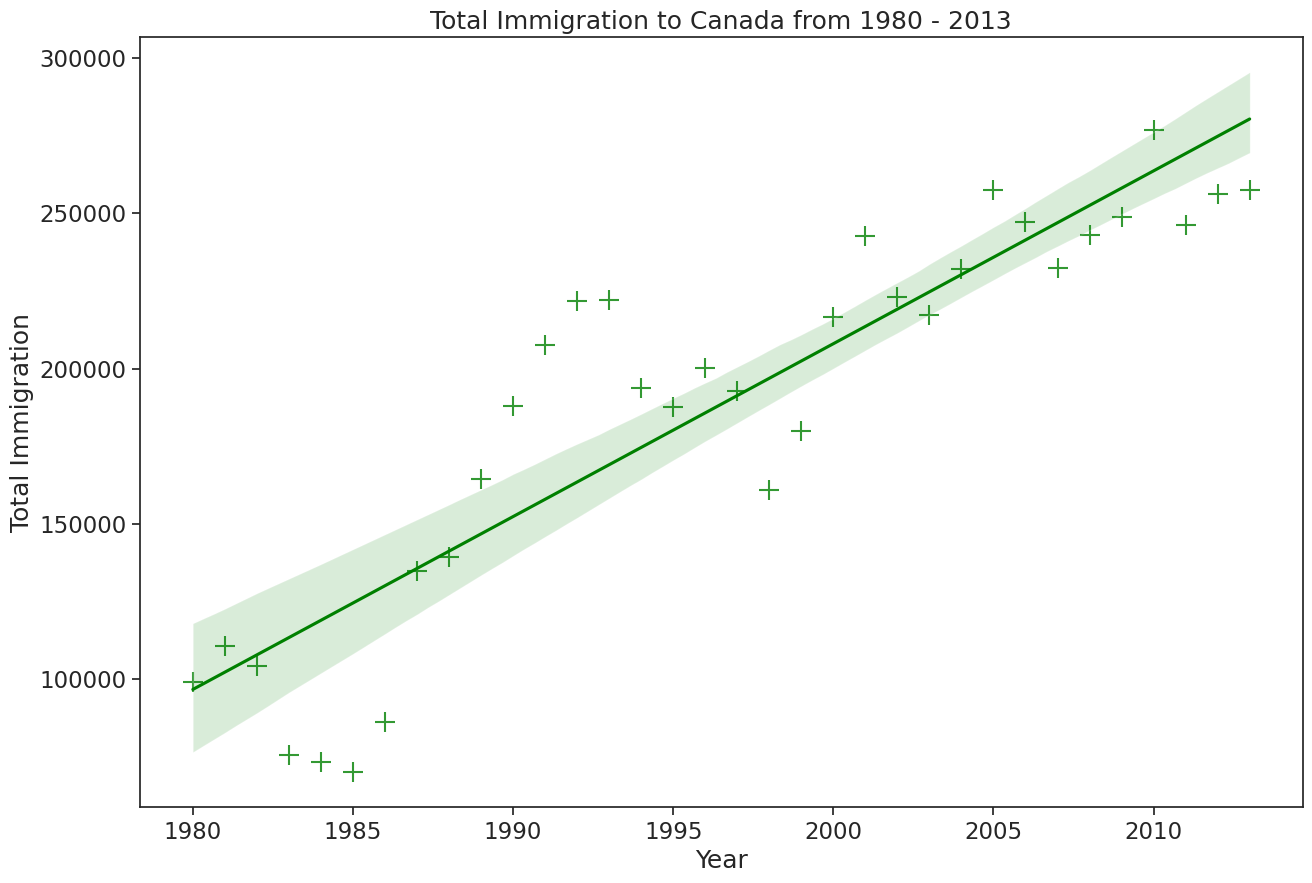

In [30]:
plt.figure(figsize=(15, 10))

sns.set(font_scale=1.5)
sns.set_style('ticks')  # change background to white background

ax = sns.regplot(x='years', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

Or to a white background with gridlines.

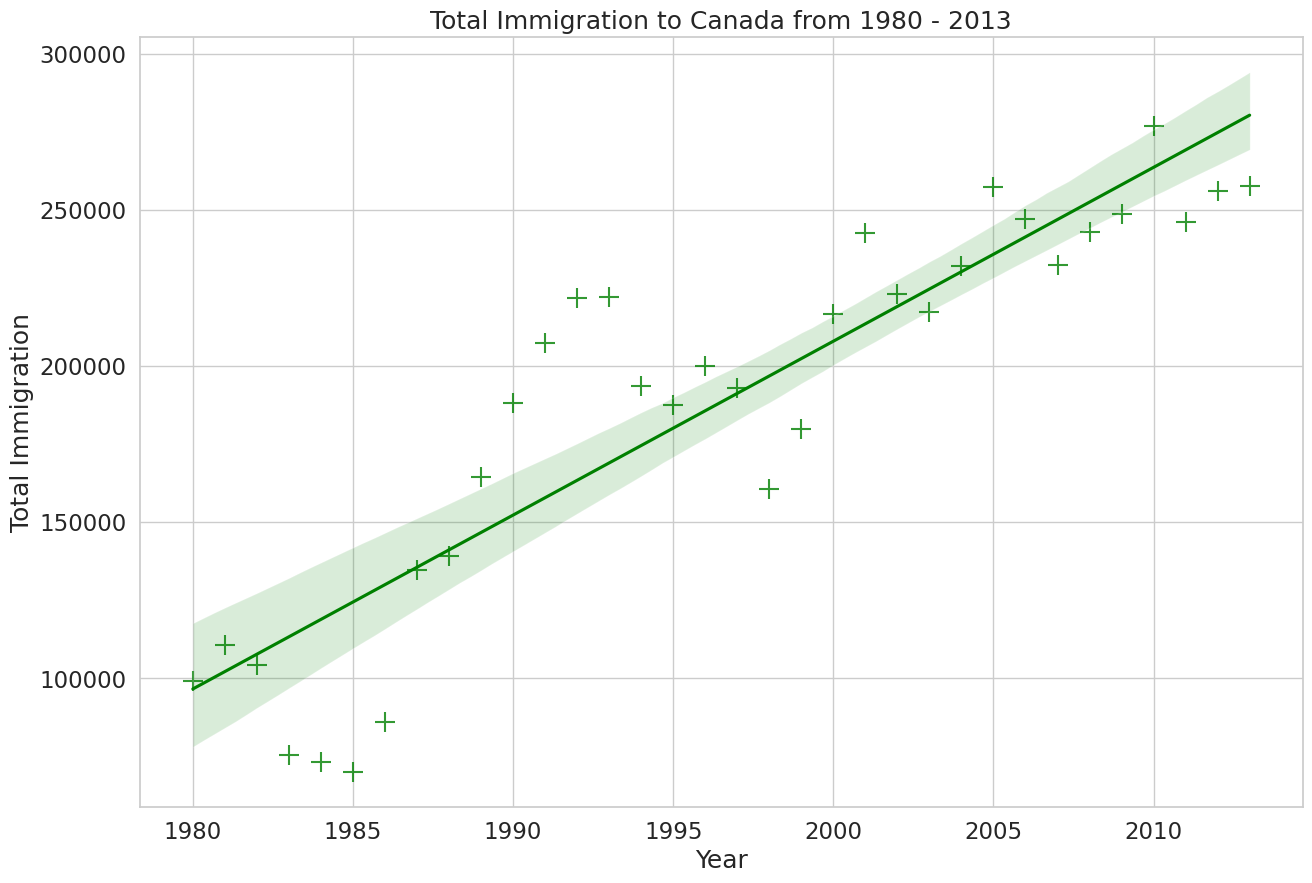

In [31]:
plt.figure(figsize=(15, 10))

sns.set(font_scale=1.5)
sns.set_style('whitegrid')

ax = sns.regplot(x='years', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()


**Question:** Use seaborn to create a scatter plot with a regression line to visualize the total immigration from Denmark, Sweden, and Norway to Canada from 1980 to 2013.

Text(0.5, 1.0, 'Total Immigration from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

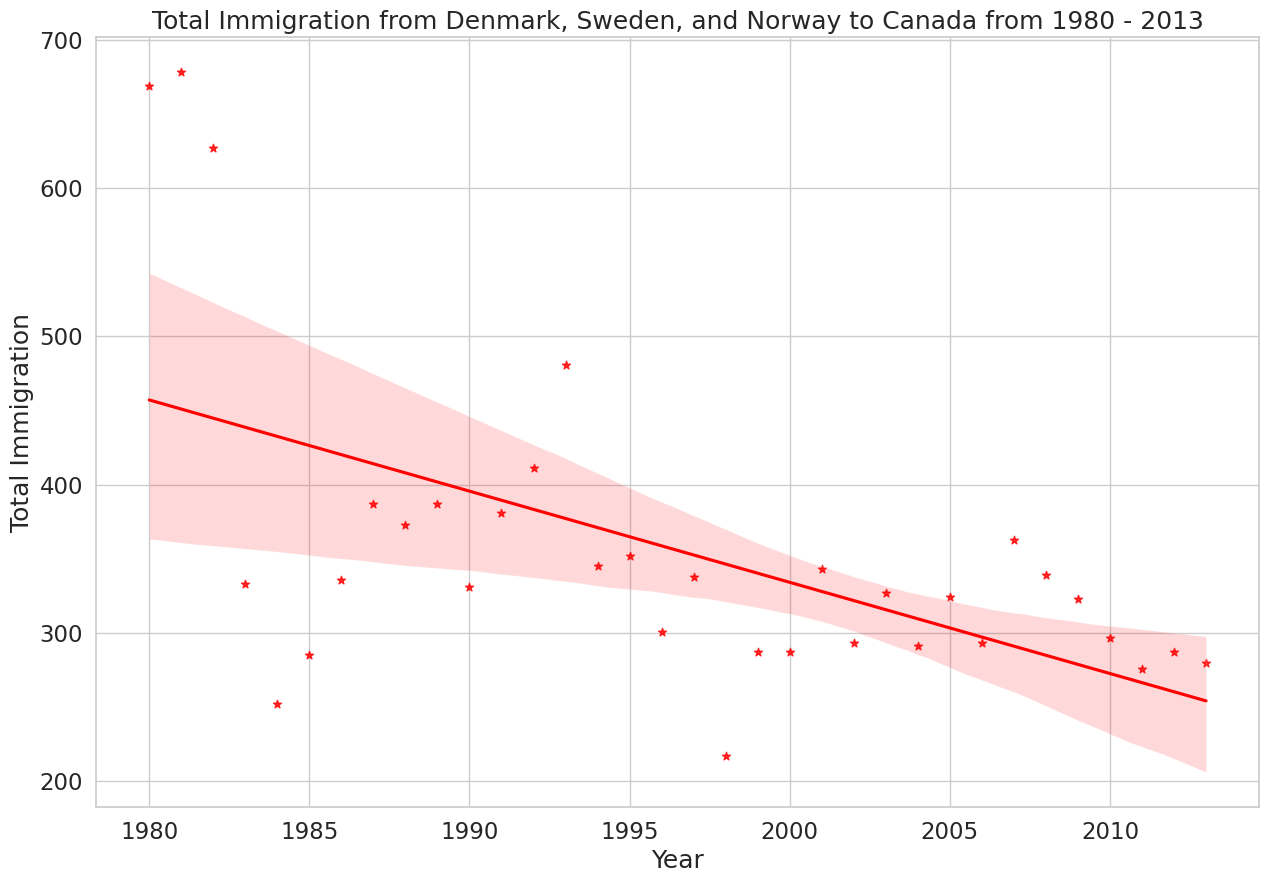

In [56]:
df_dsn = df_can.loc[["Denmark","Sweden","Norway"],years]

total_per_year = df_dsn.sum(axis=0)

df_tot = total_per_year.reset_index()
df_tot.columns = ["year","total"]

df_tot["year"] = df_tot["year"].astype(float)

plt.figure(figsize=(15,10))

ax = sns.regplot(x="year",y="total",data=df_tot, color = "red", marker="*")
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration from Denmark, Sweden, and Norway to Canada from 1980 - 2013')